In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path("../data/processed")
FIXTURES_DIR = PROCESSED_DIR / "fixtures"
METADATA_DIR = PROCESSED_DIR / "metadata"
LIVERPOOL_ID = 8
SEASON_LABELS = {21646: "Klopp 23-24", 23614: "Slot Y1 24-25", 25583: "Slot Y2 25-26"}

In [2]:
fixture_map = pd.read_csv(METADATA_DIR / "fixture_season_mapping.csv")
type_map = pd.read_csv(METADATA_DIR / "type_id_mapping.csv")

# Only fixtures with processed data
processed = fixture_map[fixture_map["has_processed_data"] == True]
print(f"Fixtures: {len(processed)} | Seasons: {processed['season_id'].value_counts().to_dict()}")

Fixtures: 101 | Seasons: {21646: 37, 23614: 34, 25583: 30}


In [3]:
frames = []
for _, row in processed.iterrows():
    f = FIXTURES_DIR / str(int(row["fixture_id"])) / "statistics.csv"
    if f.exists():
        df = pd.read_csv(f)
        df["season_id"] = row["season_id"]
        df["season"] = row["season"]
        df["manager"] = row["manager"]
        frames.append(df)

stats_df = pd.concat(frames, ignore_index=True)
# Filter to Liverpool only
lfc = stats_df[stats_df["participant_id"] == LIVERPOOL_ID].copy()
print(f"Loaded {len(lfc)} rows across {lfc['fixture_id'].nunique()} fixtures")

Loaded 4153 rows across 101 fixtures


In [4]:
lfc = lfc.merge(type_map[["type_id", "name", "stat_group"]], on="type_id", how="left")

# Pivot: one row per fixture, one col per stat
wide = lfc.pivot_table(index=["fixture_id", "season_id", "season", "manager"],
                        columns="name", values="value", aggfunc="first").reset_index()
wide.columns.name = None
print(f"Shape: {wide.shape} — {wide['season_id'].value_counts().to_dict()}")

Shape: (101, 48) — {21646: 37, 23614: 34, 25583: 30}


In [5]:
stat_cols = [c for c in wide.columns if c not in ["fixture_id", "season_id", "season", "manager"]]
season_means = wide.groupby("season")[stat_cols].agg(["mean", "std"]).round(2)
season_means

Accurate Crosses       Assists       Attacks        Ball Possession %  \
                    mean   std    mean   std    mean    std              mean   
season                                                                          
2023-24             6.05  3.36     NaN   NaN  124.54  25.67             61.73   
2024-25             4.88  2.89    1.80  1.00  109.35  25.41             58.97   
2025-26             4.27  2.73    1.28  1.14  110.47  24.32             59.57   

               Ball Safe         ... Successful Passes Percentage        \
           std      mean    std  ...                         mean   std   
season                           ...                                      
2023-24  12.04     90.11  12.28  ...                        85.30  3.32   
2024-25   8.70     79.88  14.30  ...                        86.18  2.77   
2025-26   8.55     77.93   9.40  ...                        85.27  2.79   

        Tackles       Throwins       Total Crosses        Yellowcards        
           mean   std     mean   std          mean    std        mean   std  
season                                                                       
2023-24   17.89  5.93    19.95  5.64         20.73   8.66        1.89  1.37  
2024-25   16.50  5.48    18.06  4.64         20.35   9.70        1.88  1.36  
2025-26   13.30  4.65    19.70  5.50         20.20  10.12        1.62  1.27  

[3 rows x 88 columns]

In [6]:
def cohen_d(a, b):
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else 0

comparisons = [
    ("Klopp 23-24", "Slot Y1 24-25", 21646, 23614),
    ("Slot Y1 24-25", "Slot Y2 25-26", 23614, 25583),
    ("Klopp 23-24", "Slot Y2 25-26", 21646, 25583),
]

n_tests = len(stat_cols)  # Bonferroni denominator
results = []

for label_a, label_b, sid_a, sid_b in comparisons:
    g_a = wide[wide["season_id"] == sid_a]
    g_b = wide[wide["season_id"] == sid_b]
    for col in stat_cols:
        a = g_a[col].dropna()
        b = g_b[col].dropna()
        if len(a) < 3 or len(b) < 3:
            continue
        _, p = stats.ttest_ind(a, b, equal_var=False)
        d = cohen_d(a.values, b.values)
        results.append({
            "comparison": f"{label_a} vs {label_b}",
            "metric": col,
            "mean_a": round(a.mean(), 2),
            "mean_b": round(b.mean(), 2),
            "delta": round(b.mean() - a.mean(), 2),
            "pct_change": round((b.mean() - a.mean()) / a.mean() * 100, 1) if a.mean() != 0 else None,
            "p_value": round(p, 4),
            "p_bonferroni": round(min(p * n_tests, 1.0), 4),
            "cohens_d": round(d, 3),
            "significant": p * n_tests < 0.05,
        })

results_df = pd.DataFrame(results)

In [7]:
sig = results_df[results_df["significant"]].sort_values("cohens_d", key=abs, ascending=False)
print(f"Significant after Bonferroni correction: {len(sig)} of {len(results_df)} tests")
sig[["comparison", "metric", "mean_a", "mean_b", "pct_change", "p_bonferroni", "cohens_d"]]

Significant after Bonferroni correction: 5 of 124 tests


,comparison,metric,mean_a,mean_b,pct_change,p_bonferroni,cohens_d
87,Klopp 23-24 vs Slot Y2 25-26,Ball Safe,90.11,77.93,-13.5,0.0009,1.114
28,Klopp 23-24 vs Slot Y1 24-25,Shots Outsidebox,7.19,4.41,-38.6,0.0095,0.925
110,Klopp 23-24 vs Slot Y2 25-26,Shots On Target,7.22,4.53,-37.2,0.0228,0.880
95,Klopp 23-24 vs Slot Y2 25-26,Goal Attempts,13.30,9.40,-29.3,0.0257,0.874
120,Klopp 23-24 vs Slot Y2 25-26,Tackles,17.89,13.30,-25.7,0.0315,0.862


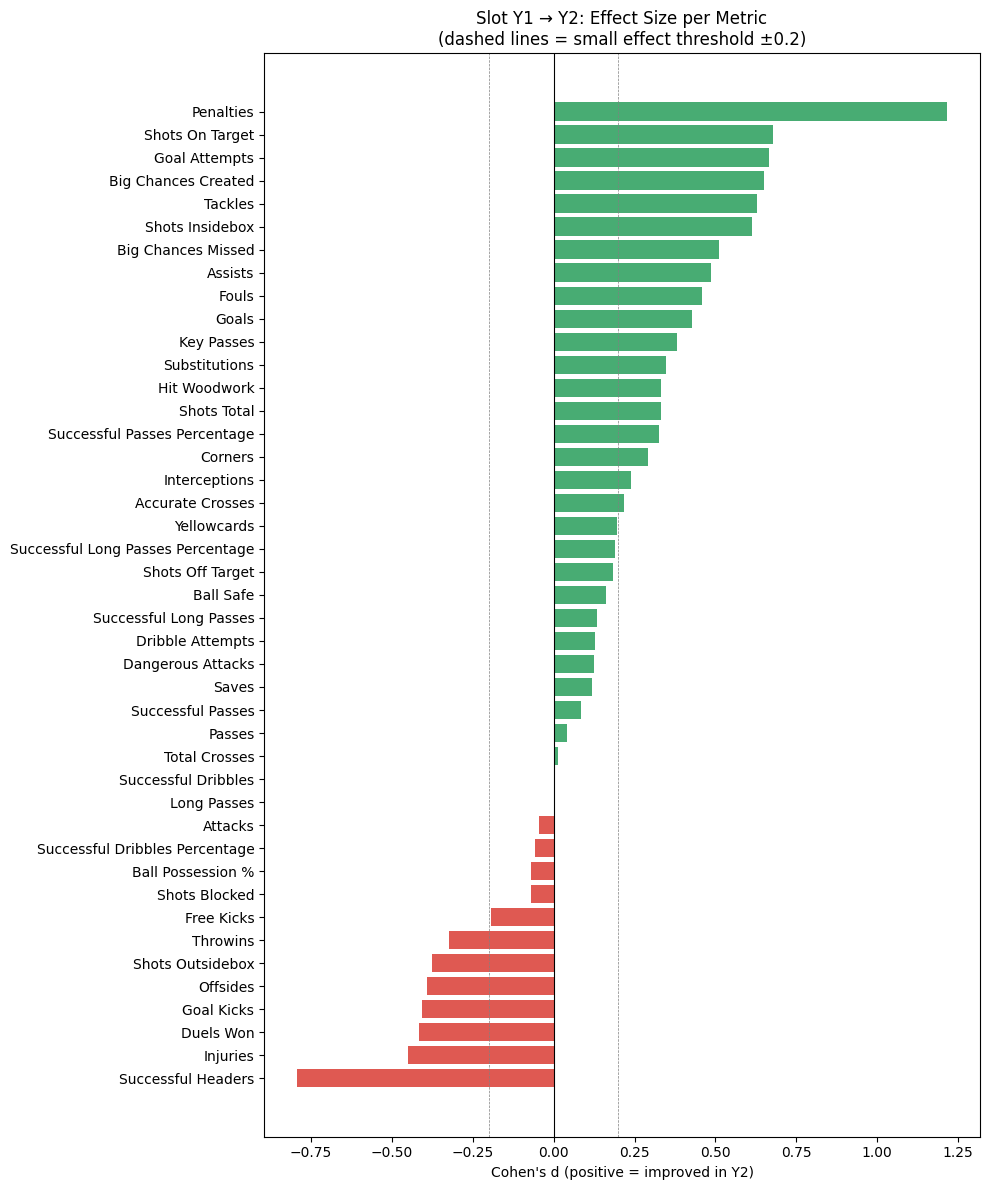

In [8]:
y1_v_y2 = results_df[results_df["comparison"] == "Slot Y1 24-25 vs Slot Y2 25-26"].copy()
y1_v_y2 = y1_v_y2.sort_values("cohens_d")

fig, ax = plt.subplots(figsize=(10, 12))
colors = ["#d73027" if d < 0 else "#1a9850" for d in y1_v_y2["cohens_d"]]
ax.barh(y1_v_y2["metric"], y1_v_y2["cohens_d"], color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(-0.2, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0.2, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel("Cohen's d (positive = improved in Y2)")
ax.set_title("Slot Y1 → Y2: Effect Size per Metric\n(dashed lines = small effect threshold ±0.2)")
plt.tight_layout()
plt.savefig("../data/processed/metadata/y1_v_y2_effect_sizes.png", dpi=150)
plt.show()

## Key Findings — Deep Dive 3.1

### Top Regressions (Y1 → Y2, largest negative effect size, Bonferroni-significant)

_Run cell 7 first, then fill in manually based on `sig` table filtered to Y1 vs Y2 with negative `cohens_d`._

| Metric | Y1 Mean | Y2 Mean | % Change | Cohen's d |
|--------|---------|---------|----------|-----------|
| TBD    | —       | —       | —        | —         |

### Top Improvements (Y1 → Y2, largest positive effect size, Bonferroni-significant)

| Metric | Y1 Mean | Y2 Mean | % Change | Cohen's d |
|--------|---------|---------|----------|-----------|
| TBD    | —       | —       | —        | —         |

### Interpretation

_Add narrative here after reviewing the results._